In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

## Case Study Approach

This case study follows a standard machine learning workflow, which includes the following key steps:

### 1. Data Loading and Preprocessing

*   **Loading Data**: Importing the CIFAR-10 dataset.
*   **Normalization**: Scaling pixel values to a [0, 1] range to facilitate model training.
*   **Data Augmentation**: Applying transformations (rotation, shifting, flipping) to the training data to increase its diversity and improve model generalization.

### 2. Model Architecture Definition

*   **Convolutional Base**: Building a Convolutional Neural Network (CNN) with multiple convolutional and pooling layers to extract features from the images.
*   **Dense Layers**: Adding fully connected layers for classification based on the extracted features.
*   **Output Layer**: A softmax activation layer for multi-class classification (10 classes for CIFAR-10).

### 3. Model Compilation and Training

*   **Optimizer**: Using the Adam optimizer for efficient gradient descent.
*   **Loss Function**: Employing `sparse_categorical_crossentropy` suitable for integer-encoded labels.
*   **Metrics**: Monitoring accuracy during training and evaluation.
*   **Training**: Fitting the model to the augmented training data, with validation on the test set to observe performance and detect overfitting.

### 4. Model Evaluation

*   **Test Set Evaluation**: Assessing the model's performance on unseen test data to determine its generalization capability.
*   **Visualization**: Plotting training and validation accuracy over epochs to understand training progress and identify potential issues like overfitting or underfitting.

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0


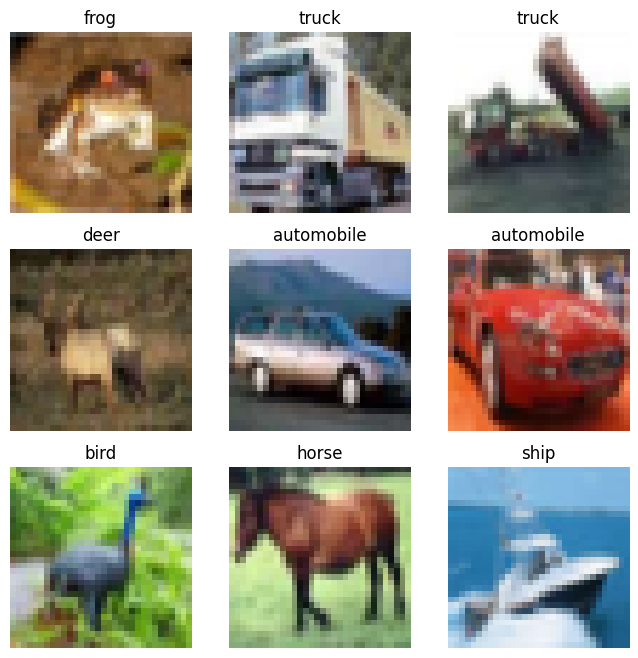

In [ ]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)


In [ ]:
model = models.Sequential()



In [ ]:
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))



In [ ]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))


In [ ]:
model.add(layers.Conv2D(64, (3,3), activation='relu'))



In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [ ]:
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=10,
                    validation_data=(x_test, y_test))



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 109ms/step - accuracy: 0.3178 - loss: 1.8346 - val_accuracy: 0.5311 - val_loss: 1.2993
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 110ms/step - accuracy: 0.5020 - loss: 1.3762 - val_accuracy: 0.5829 - val_loss: 1.1692
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.5569 - loss: 1.2452 - val_accuracy: 0.5839 - val_loss: 1.1568
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 108ms/step - accuracy: 0.5852 - loss: 1.1668 - val_accuracy: 0.6141 - val_loss: 1.1213
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.6109 - loss: 1.0998 - val_accuracy: 0.6489 - val_loss: 1.0260
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.6305 - loss: 1.0420 - val_accuracy: 0.6729 - val_loss: 0.9319
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.6427 - loss: 0.9989 - val_accuracy: 0.6534 - val_loss: 1.0092
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.6547 - loss: 0.9791 - v

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7154 - loss: 0.8468
Test Accuracy: 0.7110000252723694


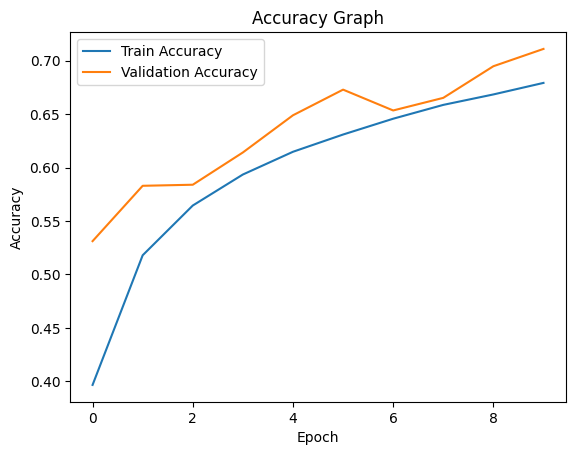

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()